100


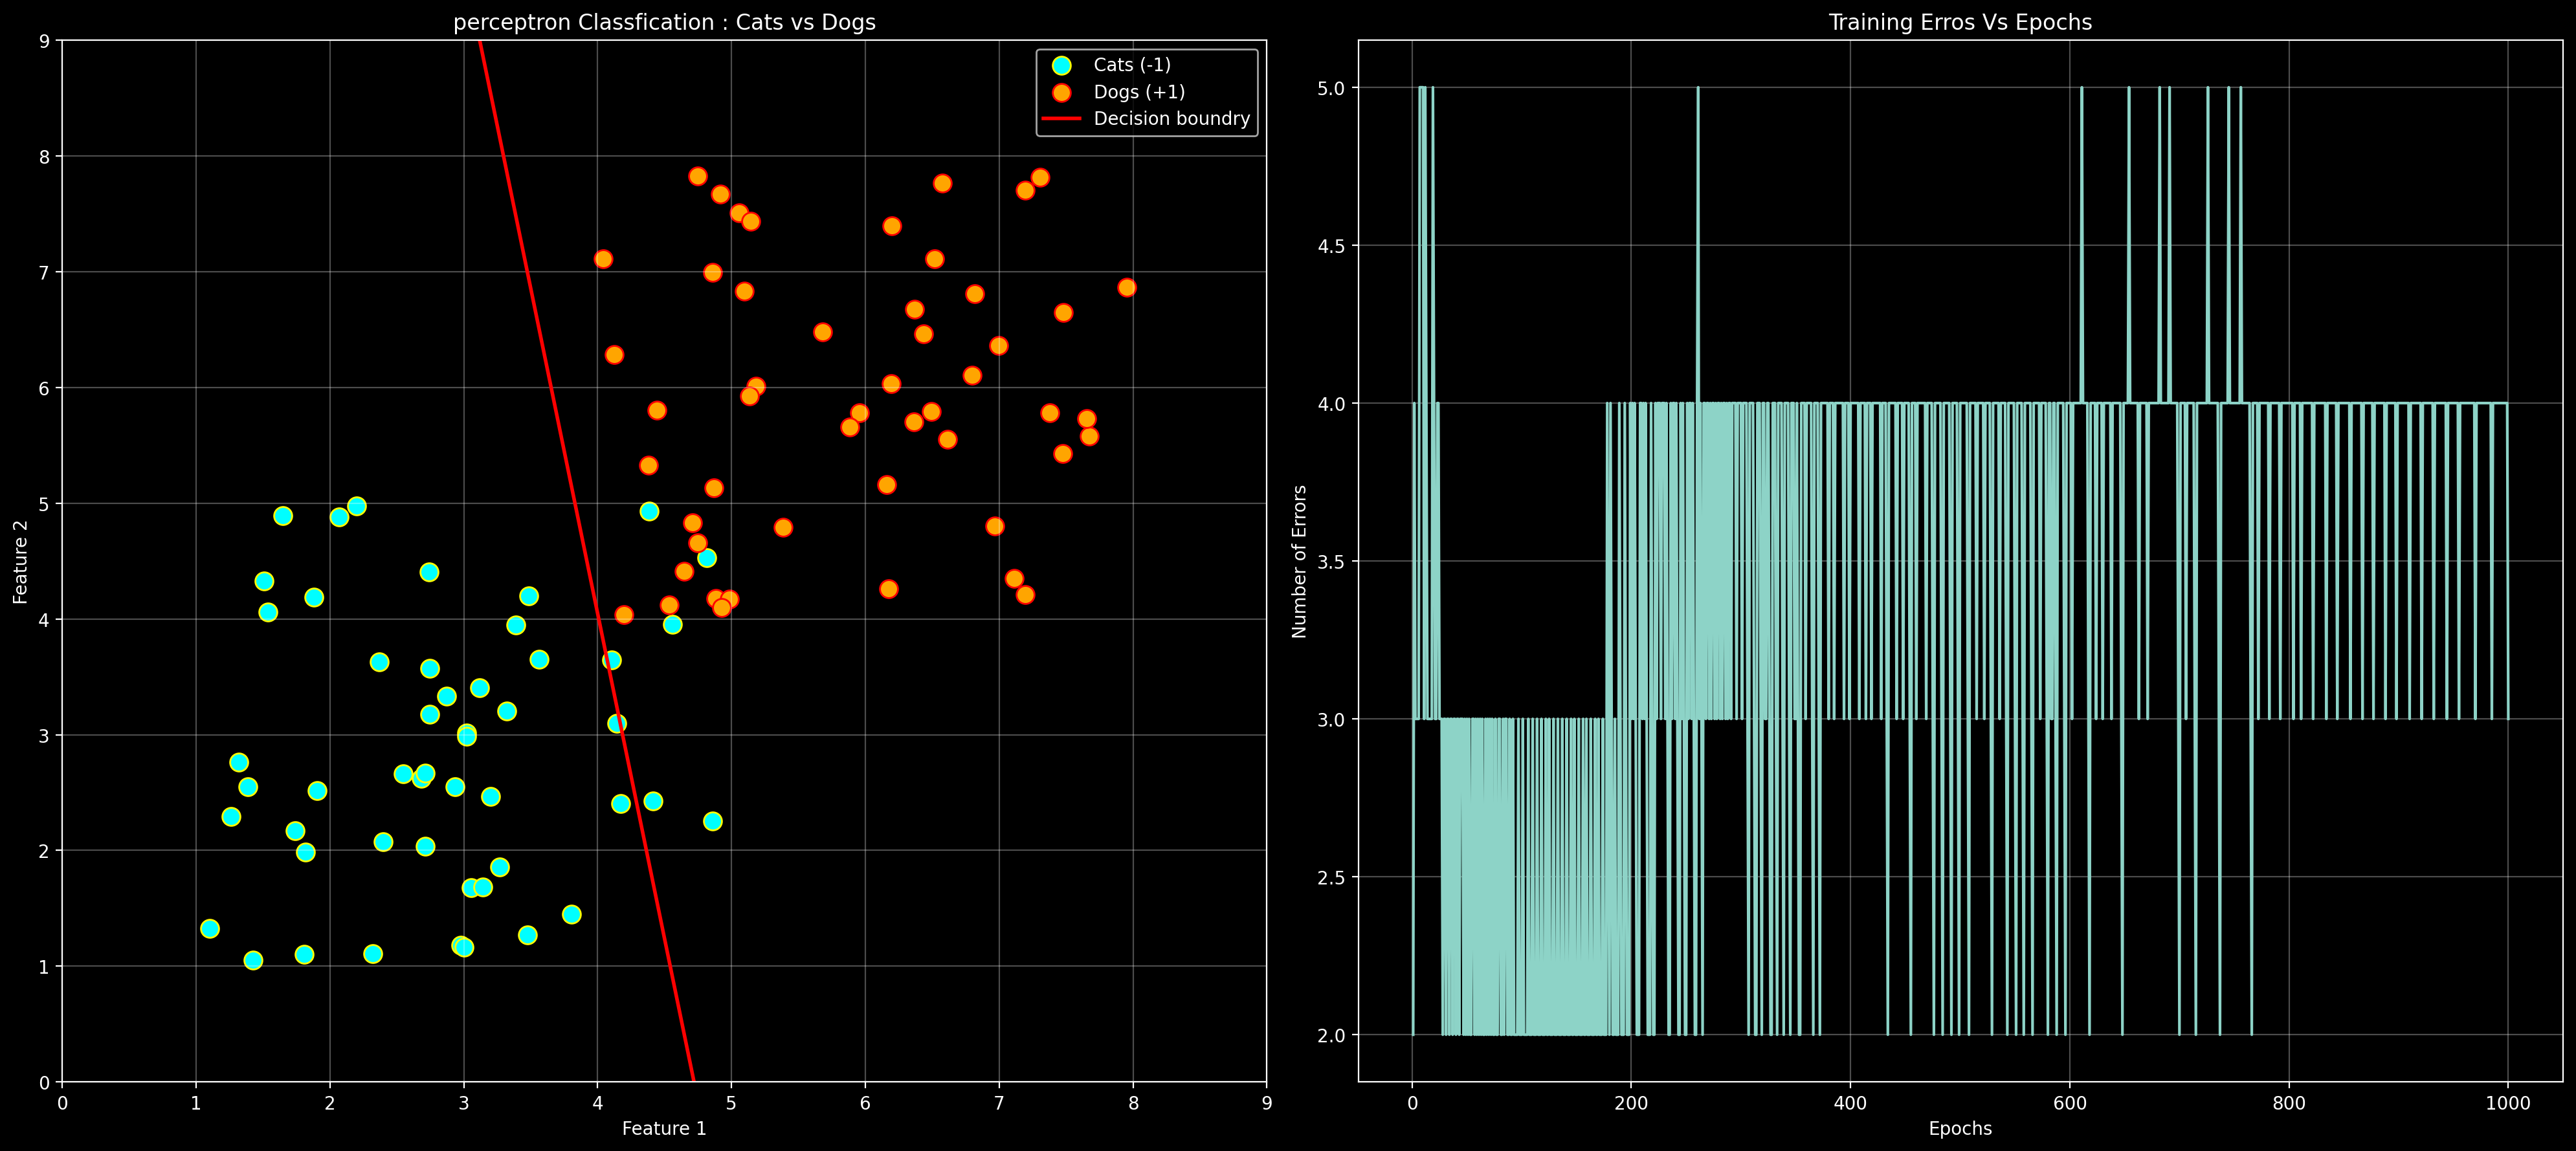

final w1:8.8512
final w1:1.5757
final w1:-41.7812
Training Stopped at epoch: 1000
Accuracy :94.00%


In [28]:
import numpy as np 
import matplotlib.pyplot as plt


plt.style.use('dark_background')
np.random.seed(2)

n_samples = 50

cats_x1 = np.random.uniform(1,5,n_samples)
cats_x2 = np.random.uniform(1,5,n_samples)
cats = np.column_stack([cats_x1,cats_x2])
cats_labels = -np.ones(n_samples)

dogs_x1 = np.random.uniform(4,8,n_samples)
dogs_x2 = np.random.uniform(4,8,n_samples)
dogs = np.column_stack([dogs_x1,dogs_x2])
dogs_labels = np.ones(n_samples)

X = np.vstack([cats,dogs])
y = np.concatenate([cats_labels,dogs_labels])


plt.figure(figsize=(20,9),dpi = 200)
plt.subplot(1,2,1)
plt.scatter(cats[:,0],cats[:,1],c = 'cyan',s = 100,marker='o',label='Cats (-1)',edgecolors='yellow')
plt.scatter(dogs[:,0],dogs[:,1],c = 'orange',s = 100,marker='o',label='Dogs (+1)',edgecolors='red')


#intialize preceptron weights 

w1 = np.random.rand(1)[0]
w2 = np.random.rand(1)[0]
b = np.random.rand(1)[0]

eta = 0.1
epochs = 1000
errors = np.zeros(epochs)

print(len(X))

for i in range(epochs):
    error_count = 0
    for j in range(len(X)):
        z = (w1 * X[j,0]) + (w2 * X[j,1]) + b
        yhat = 1 if z >=0 else -1

        if (yhat != y[j]):
            w1 += eta * (y[j] - yhat) * X[j,0]
            w2 += eta * (y[j] -yhat) * X[j,1]
            b += eta * (y[j] - yhat)
            error_count += 1


    errors[i] = error_count
    if error_count ==0 :
        break


x1_vals = np.linspace(0,9,100)
x2_vals = -(w1 * x1_vals +b)/w2

plt.plot(x1_vals,x2_vals,'r-',linewidth =2,label = 'Decision boundry')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('perceptron Classfication : Cats vs Dogs')
plt.grid(True,alpha=.3)
plt.xlim(0,9)
plt.ylim(0,9)


plt.subplot(1,2,2)
plt.plot(range(1,i+2),errors[:i+1])
plt.xlabel('Epochs')
plt.ylabel('Number of Errors')
plt.title("Training Erros Vs Epochs")
plt.grid(True,alpha=.3)

plt.tight_layout()
plt.show()


print(f'final w1:{w1:0.4f}')
print(f'final w1:{w2:0.4f}')
print(f'final w1:{b:0.4f}')
print(f'Training Stopped at epoch: {i+1}')

#calculate accuarcy
predications = np.array([(1 if ((w1 * X[j,0]) + (w2 * X[j,1]) + b) >=0 else -1) for j in range(len(X))])
accuracy = np.mean(predications==y)
print(f'Accuracy :{accuracy * 100:0.2f}%')



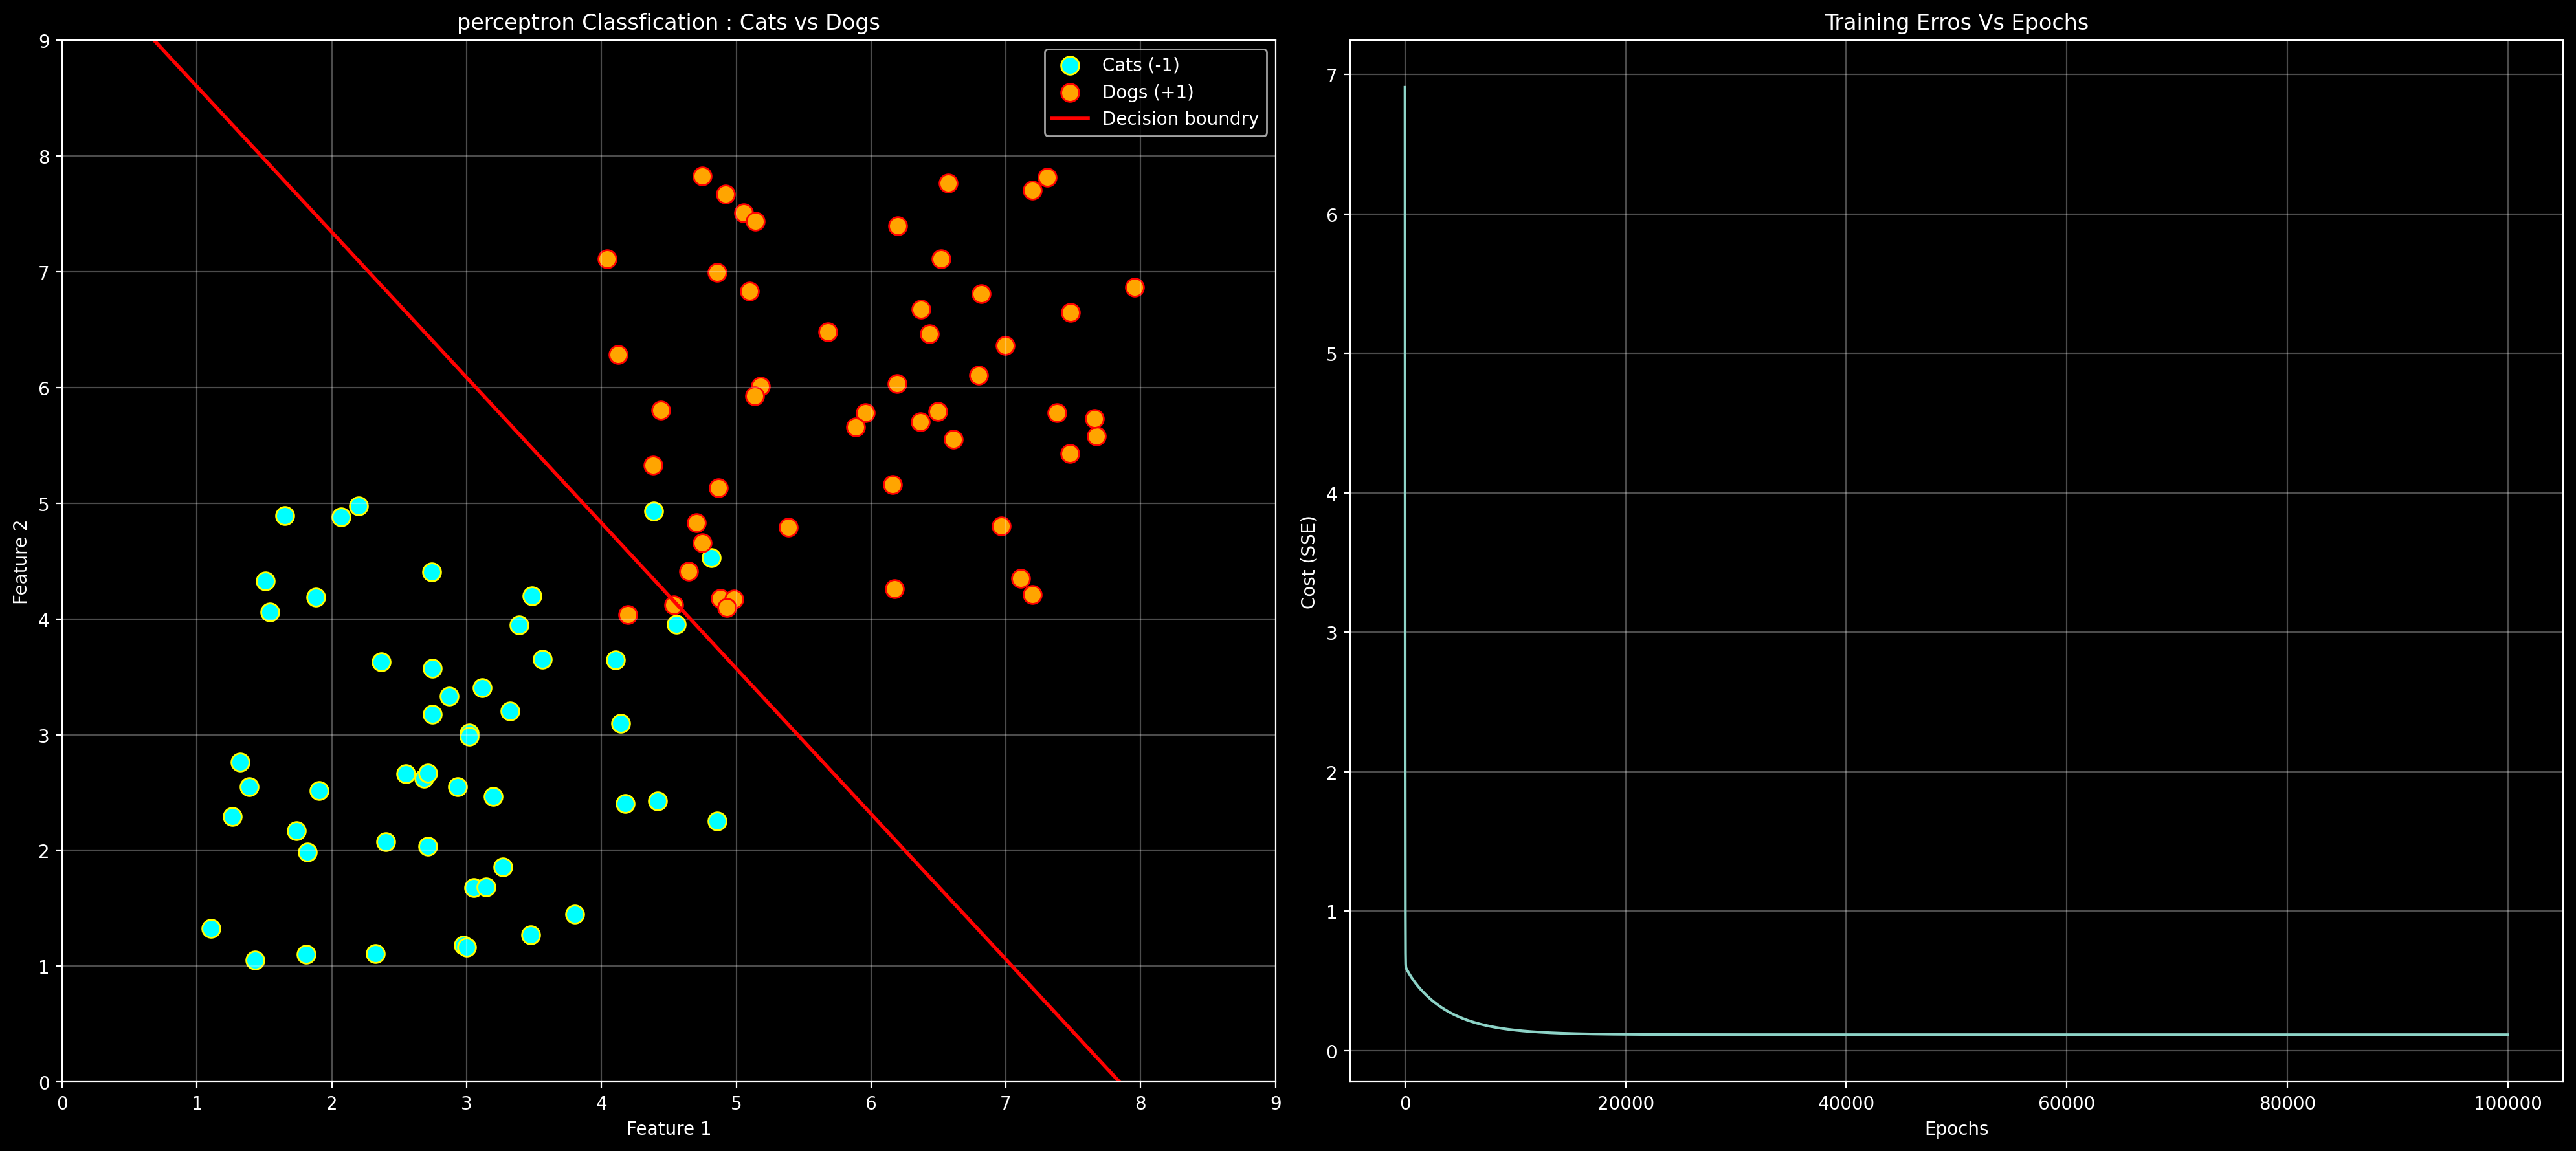

final w including bais[-2.20734276  0.28141928  0.22404009]
final w1:0.2814
final w1:0.2240
final w1:-2.2073
final cost :0.1133
Training Stopped at epoch: 100000
Accuracy :96.00%


In [30]:



plt.style.use('dark_background')
np.random.seed(2)

n_samples = 50

cats_x1 = np.random.uniform(1,5,n_samples)
cats_x2 = np.random.uniform(1,5,n_samples)
cats = np.column_stack([cats_x1,cats_x2])
cats_labels = -np.ones(n_samples)

dogs_x1 = np.random.uniform(4,8,n_samples)
dogs_x2 = np.random.uniform(4,8,n_samples)
dogs = np.column_stack([dogs_x1,dogs_x2])
dogs_labels = np.ones(n_samples)

X = np.vstack([cats,dogs])
y = np.concatenate([cats_labels,dogs_labels])

X_bais = np.column_stack([np.ones(len(X)),X])

plt.figure(figsize=(20,9),dpi = 200)
plt.subplot(1,2,1)
plt.scatter(cats[:,0],cats[:,1],c = 'cyan',s = 100,marker='o',label='Cats (-1)',edgecolors='yellow')
plt.scatter(dogs[:,0],dogs[:,1],c = 'orange',s = 100,marker='o',label='Dogs (+1)',edgecolors='red')


#intialize preceptron weights 

w = np.random.rand(3)
eta = 0.001
epochs = 100000
costVals = np.zeros(epochs)

for i in range(epochs):

    z = X_bais @ w

    error = y - z 

    w += eta * (X_bais.T @ error) / len(X)

    costVals[i] = 0.5 * np.mean(error ** 2)


    if(costVals[i] < 1e-5):
        break


b = w[0]
w1 = w[1]
w2 = w[2]


x1_vals = np.linspace(0,9,100)
x2_vals = -(w1 * x1_vals +b)/w2

plt.plot(x1_vals,x2_vals,'r-',linewidth =2,label = 'Decision boundry')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('perceptron Classfication : Cats vs Dogs')
plt.grid(True,alpha=.3)
plt.xlim(0,9)
plt.ylim(0,9)


plt.subplot(1,2,2)
plt.plot(range(1,i+2),costVals[:i+1])
plt.xlabel('Epochs')
plt.ylabel('Cost (SSE)')
plt.title("Training Erros Vs Epochs")
plt.grid(True,alpha=.3)

plt.tight_layout()
plt.show()

print(f'final w including bais{w}')
print(f'final w1:{w1:0.4f}')
print(f'final w1:{w2:0.4f}')
print(f'final w1:{b:0.4f}')
print(f'final cost :{costVals[i]:0.4f}')
print(f'Training Stopped at epoch: {i+1}')

#calculate accuarcy
predications = np.where(X_bais @ w > 0 , 1 ,-1)
accuracy = np.mean(predications==y)
print(f'Accuracy :{accuracy * 100:0.2f}%')